In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import mean_squared_error
from train import run_training_pipeline

In [2]:
test_df, garch_predictions, lstm_model, X_test, scaler, seq_length = run_training_pipeline()

Prepping and Training LSTM...
Epoch 10/50 | Loss: 0.009811
Epoch 20/50 | Loss: 0.003003
Epoch 30/50 | Loss: 0.001757
Epoch 40/50 | Loss: 0.001082
Epoch 50/50 | Loss: 0.000856
Pipeline Ready.


In [3]:
lstm_model.eval()
with torch.no_grad():
    lstm_scaled_preds = lstm_model(torch.tensor(X_test, dtype=torch.float32)).numpy()

dummy = np.zeros((len(lstm_scaled_preds), 3))
dummy[:,1] = lstm_scaled_preds[:,0]
lstm_predictions = scaler.inverse_transform(dummy)[:,1]

In [4]:
target_length = len(lstm_predictions)
actual_vol = test_df['realized_vol'].values[-target_length:]
garch_aligned = garch_predictions[-target_length:]
dates = test_df.index[-target_length:]

In [5]:
garch_rmse = np.sqrt(mean_squared_error(actual_vol, garch_aligned))
lstm_rmse = np.sqrt(mean_squared_error(actual_vol, lstm_predictions))

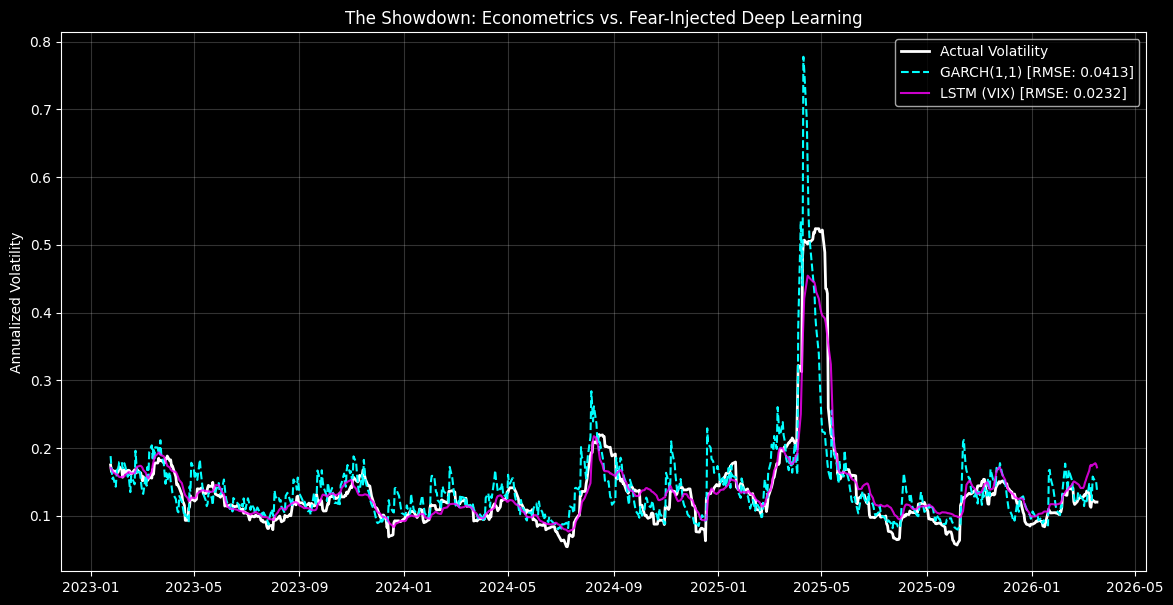

In [6]:
plt.style.use('dark_background')
plt.figure(figsize=(14, 7))
plt.plot(dates, actual_vol, label="Actual Volatility", color='white', linewidth=2)
plt.plot(dates, garch_aligned, label=f"GARCH(1,1) [RMSE: {garch_rmse:.4f}]", color='cyan', linestyle='dashed')
plt.plot(dates, lstm_predictions, label=f"LSTM (VIX) [RMSE: {lstm_rmse:.4f}]", color='magenta', alpha=0.8)
plt.title("The Showdown: Econometrics vs. Fear-Injected Deep Learning")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.2)
plt.show()